# Sorcha SSP Linking Config Comparison

Three full Sorcha re-runs on the pure-S3M population, varying only two SSP linking parameters.
Everything else is identical: same S3M orbits, same VDP grid maps (`prob_maps_grid_s3m/`), same digest2 binary.

**Goal:** attribute the Sorcha-vs-benchmark TNO gap to specific linking mechanics.  
**Finding:** TNO barely moves across cases; NEO drops ~16% under real LSST linking (case2).

| Case | `SSP_number_tracklets` | `SSP_separation_threshold` | Isolates |
|------|:---:|:---:|----------|
| **case3** | 1 | ~0" | Neither constraint — reproduces the original no-linking run |
| **case1** | 1 | 0.5" | Motion threshold only (one qualifying tracklet anywhere in 2 yrs) |
| **case2** | 3 | 0.5" | Full LSST linking — 3 tracklets within 15 days (real SSP baseline) |

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import precision_recall_curve, roc_auc_score

# ── helpers ──────────────────────────────────────────────────────────────────
def roc_xy(yy, s):
    """Precision-recall → (completeness%, contamination%, bestF1, best_compl%, best_contam%)"""
    p, r, _ = precision_recall_curve(yy, s)
    f1 = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r)>0)
    bi = int(np.argmax(f1[:-1]))
    return r*100, (1-p)*100, f1[bi], r[bi]*100, (1-p[bi])*100

def add_absdlon(df):
    """Parse |Δλ☉| from prob_map_file column (e.g. prob_maps_grid_dlon-020_lat+03.npz → 20)."""
    def _parse(pmf):
        m = re.search(r'dlon([+-]\d+)', str(pmf))
        return abs(int(m.group(1))) if m else np.nan
    df = df.copy()
    df['absdlon'] = df['prob_map_file'].map(_parse)
    return df

POPS   = ['NEO', 'MBA', 'TNO', 'Trojan', 'other']
COLORS = {'VDP': 'tab:blue', 'digest2': 'tab:orange'}
LSTYLES = {'case3': '-', 'case1': '--', 'case2': ':'}
LABELS  = {
    'case3': 'case3 (tk=1, sep≈0, baseline)',
    'case1': 'case1 (tk=1, sep=0.5")',
    'case2': 'case2 (tk=3, sep=0.5" — real LSST)',
}

In [2]:
# ── load parquets ─────────────────────────────────────────────────────────────
BASE = 'docs'

cases = {}
for c in ['case1', 'case2', 'case3']:
    df = pd.read_parquet(f'{BASE}/sorcha_comparison_{c}.parquet')
    df = add_absdlon(df)
    df['is_neo'] = (df['population'] == 'NEO')
    cases[c] = df
    print(f'{c}: {len(df):,} rows  |  NaN vdp={df.P_NEO_vdp.isna().sum()}  d2={df.P_NEO_d2.isna().sum()}')

print('done')

case1: 648,769 rows  |  NaN vdp=0  d2=0
case2: 624,783 rows  |  NaN vdp=0  d2=0
case3: 648,828 rows  |  NaN vdp=0  d2=0
done


## Section 1 — Population Summary Tables

What does each case actually recover?  The table below shows absolute counts and percentages for every population in the scored subsample (all NEOs + 500 k non-NEOs, sampled proportionally from the VDP-scored tracklets).

In [3]:
# ── population count / percentage table ──────────────────────────────────────
rows = []
for c, df in cases.items():
    vc = df['population'].value_counts()
    total = len(df)
    row = {'Case': c,
           'SSP tracklets': {'case1':1,'case2':3,'case3':1}[c],
           'Sep. thresh."': {'case1':'0.5','case2':'0.5','case3':'~0'}[c],
           'Total rows': total}
    for p in POPS:
        n = int(vc.get(p, 0))
        row[f'{p} N'] = n
        row[f'{p} %'] = f'{100*n/total:.1f}'
    rows.append(row)

pop_tbl = pd.DataFrame(rows).set_index('Case')

# ── split into two display tables ─────────────────────────────────────────────
cfg_cols = ['SSP tracklets', 'Sep. thresh."', 'Total rows']
print('=== Linking config ===')
display(pop_tbl[cfg_cols])

count_cols = [f'{p} N' for p in POPS]
pct_cols   = [f'{p} %' for p in POPS]

print('\n=== Population counts ===')
display(pop_tbl[count_cols].rename(columns=lambda c: c.replace(' N','')))

print('\n=== Population % of total ===')
display(pop_tbl[pct_cols].rename(columns=lambda c: c.replace(' %','')))

=== Linking config ===


,SSP tracklets,"Sep. thresh.""",Total rows
Case,,,
case1,1,0.5,648769
case2,3,0.5,624783
case3,1,~0,648828



=== Population counts ===


,NEO,MBA,TNO,Trojan,other
Case,,,,,
case1,148773,463419,4965,12723,18889
case2,124748,463831,4742,12788,18674
case3,148828,463698,4930,12743,18629



=== Population % of total ===


,NEO,MBA,TNO,Trojan,other
Case,,,,,
case1,22.9,71.4,0.8,2.0,2.9
case2,20.0,74.2,0.8,2.0,3.0
case3,22.9,71.5,0.8,2.0,2.9


In [4]:
# ── delta table: how each pop changes from case3 → case1 → case2 ─────────────
base = cases['case3']['population'].value_counts()
delta_rows = []
for c in ['case1', 'case2']:
    vc = cases[c]['population'].value_counts()
    row = {'vs case3 →': c}
    for p in POPS:
        d = int(vc.get(p,0)) - int(base.get(p,0))
        row[p] = f'{d:+,}'
    delta_rows.append(row)
print('=== Change from case3 baseline ===')
display(pd.DataFrame(delta_rows).set_index('vs case3 →'))

=== Change from case3 baseline ===


,NEO,MBA,TNO,Trojan,other
vs case3 →,,,,,
case1,-55,-279,+35,-20,+260
case2,"-24,080",+133,-188,+45,+45


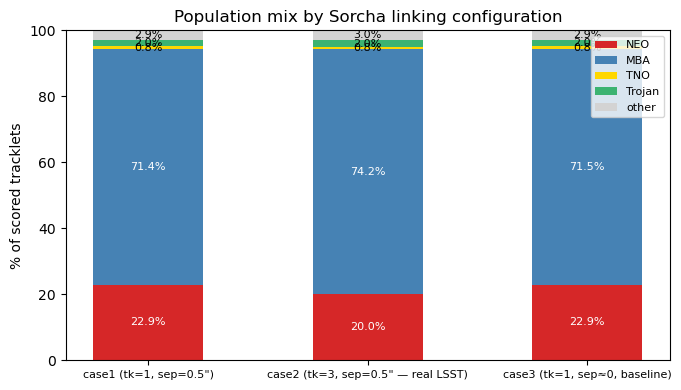

In [5]:
# ── stacked bar: population mix per case ─────────────────────────────────────
pop_colors = {'NEO':'tab:red','MBA':'steelblue','TNO':'gold','Trojan':'mediumseagreen','other':'lightgrey'}

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(3)
labels_x = list(cases.keys())
bottoms = np.zeros(3)

for pop in POPS:
    vals = np.array([100 * cases[c]['population'].value_counts().get(pop,0) / len(cases[c])
                     for c in cases])
    ax.bar(x, vals, bottom=bottoms, color=pop_colors[pop], label=pop, width=0.5)
    # annotate if large enough
    for xi, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 0.5:
            ax.text(xi, b + v/2, f'{v:.1f}%', ha='center', va='center', fontsize=8, color='white' if pop in ('MBA','NEO') else 'black')
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels([LABELS[c] for c in cases], fontsize=8)
ax.set_ylabel('% of scored tracklets')
ax.set_ylim(0, 100)
ax.legend(loc='upper right', fontsize=8)
ax.set_title('Population mix by Sorcha linking configuration')
plt.tight_layout()
plt.savefig('Figures/case_population_mix.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 2 — ROC Comparison across Cases

One panel per case, VDP vs digest2.  Then an overlay plot to see whether linking shifts the curves.

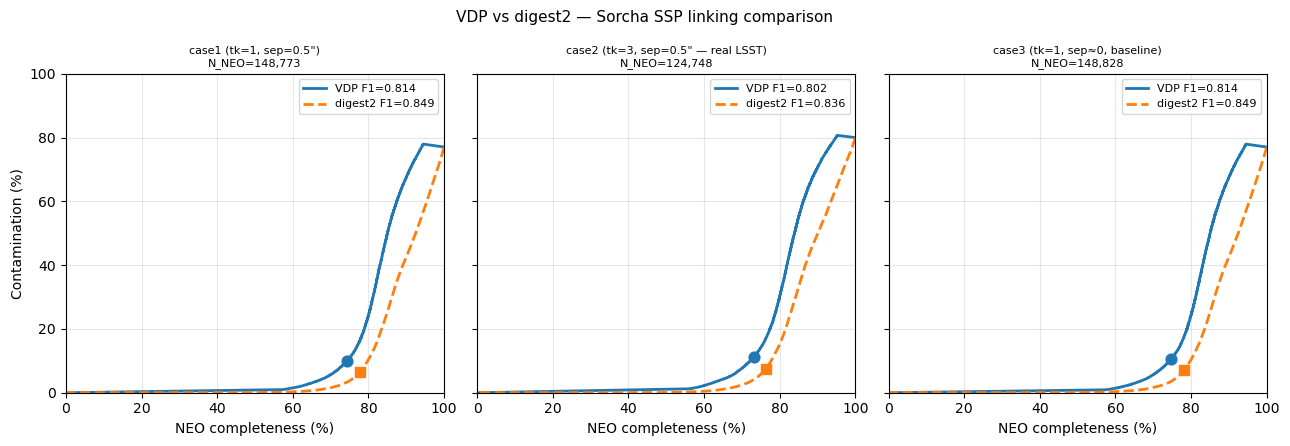

In [6]:
# ── 1×3 ROC panels, one per case ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharex=True, sharey=True)

f1_rows = []
for ax, (c, df) in zip(axes, cases.items()):
    yy = df['is_neo'].values
    cv, kv, fv, mcv, mkv = roc_xy(yy, df['P_NEO_vdp'].values)
    cd, kd, fd, mcd, mkd = roc_xy(yy, df['P_NEO_d2'].values)
    auc_v = roc_auc_score(yy, df['P_NEO_vdp'].values)
    auc_d = roc_auc_score(yy, df['P_NEO_d2'].values)

    ax.plot(cv, kv, lw=2, color=COLORS['VDP'],    label=f'VDP F1={fv:.3f}')
    ax.plot(cd, kd, lw=2, color=COLORS['digest2'], ls='--', label=f'digest2 F1={fd:.3f}')
    ax.scatter([mcv], [mkv], color=COLORS['VDP'],    s=60, zorder=5)
    ax.scatter([mcd], [mkd], color=COLORS['digest2'], s=60, marker='s', zorder=5)
    ax.set_title(LABELS[c] + f'\nN_NEO={int(yy.sum()):,}', fontsize=8)
    ax.set_xlim(0,100); ax.set_ylim(0,100)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    f1_rows.append({'Case': c,
                    'N_NEO': int(yy.sum()), 'N_total': len(df),
                    'VDP F1': round(fv,3), 'VDP compl%': round(mcv,1), 'VDP contam%': round(mkv,1), 'VDP AUC': round(auc_v,3),
                    'd2 F1': round(fd,3),  'd2 compl%': round(mcd,1),  'd2 contam%': round(mkd,1),  'd2 AUC': round(auc_d,3)})

for ax in axes:
    ax.set_xlabel('NEO completeness (%)')
axes[0].set_ylabel('Contamination (%)')
fig.suptitle('VDP vs digest2 — Sorcha SSP linking comparison', fontsize=11)
plt.tight_layout()
plt.savefig('Figures/case_roc_panels.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ── F1 / AUC summary table ────────────────────────────────────────────────────
f1_tbl = pd.DataFrame(f1_rows).set_index('Case')
print('=== ROC summary ===')
display(f1_tbl)

=== ROC summary ===


,N_NEO,N_total,VDP F1,VDP compl%,VDP contam%,VDP AUC,d2 F1,d2 compl%,d2 contam%,d2 AUC
Case,,,,,,,,,,
case1,148773,648769,0.814,74.4,10.1,0.879,0.849,77.8,6.6,0.943
case2,124748,624783,0.802,73.1,11.2,0.880,0.836,76.4,7.6,0.938
case3,148828,648828,0.814,74.8,10.6,0.879,0.849,78.2,7.2,0.943


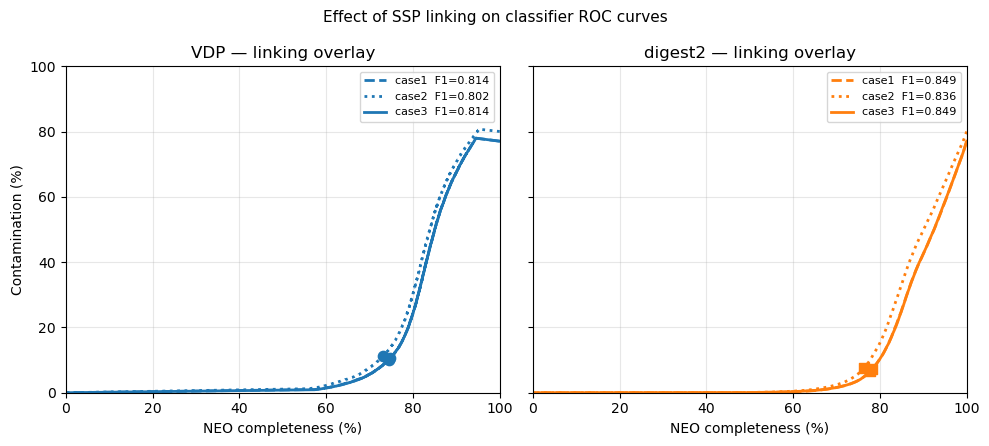

In [8]:
# ── Overlay: VDP curves for all 3 cases (left) | digest2 curves (right)
# Directly shows whether linking shifts the ROC curve
fig, (ax_v, ax_d) = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)

for c, df in cases.items():
    yy = df['is_neo'].values
    cv, kv, fv, mcv, mkv = roc_xy(yy, df['P_NEO_vdp'].values)
    cd, kd, fd, mcd, mkd = roc_xy(yy, df['P_NEO_d2'].values)
    ls = LSTYLES[c]

    ax_v.plot(cv, kv, lw=2, ls=ls, color=COLORS['VDP'],    label=f'{c}  F1={fv:.3f}')
    ax_v.scatter([mcv], [mkv], color=COLORS['VDP'], s=55, zorder=5)

    ax_d.plot(cd, kd, lw=2, ls=ls, color=COLORS['digest2'], label=f'{c}  F1={fd:.3f}')
    ax_d.scatter([mcd], [mkd], color=COLORS['digest2'], s=55, marker='s', zorder=5)

for ax, title in [(ax_v,'VDP'), (ax_d,'digest2')]:
    ax.set_xlim(0,100); ax.set_ylim(0,100)
    ax.set_xlabel('NEO completeness (%)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    ax.set_title(f'{title} — linking overlay')
ax_v.set_ylabel('Contamination (%)')

fig.suptitle('Effect of SSP linking on classifier ROC curves', fontsize=11)
plt.tight_layout()
plt.savefig('Figures/case_roc_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Direction-Bin Breakdown

Does the effect of linking vary with antisun-relative longitude?  
Two rows (case3 = baseline, case2 = real LSST), five direction bins.  
Also tabulates **NEO counts per bin** to show where the 16% case2 NEO loss falls.

In [9]:
# ── NEO count per direction bin per case ─────────────────────────────────────
BINS = [(0,20),(20,40),(40,70),(70,110),(110,141)]
BIN_LABS = ['0–20°','20–40°','40–70°','70–110°','110–141°']

bin_rows = []
for lo, hi in BINS:
    row = {'Bin': f'{lo}–{hi}°'}
    for c, df in cases.items():
        m = (df.absdlon >= lo) & (df.absdlon < hi)
        n_neo = int((df.loc[m,'population'] == 'NEO').sum())
        n_tot = int(m.sum())
        row[f'{c}_NEO'] = n_neo
        row[f'{c}_total'] = n_tot
        row[f'{c}_neo%'] = f'{100*n_neo/n_tot:.1f}' if n_tot else '—'
    # delta: case3 → case2
    d = row['case2_NEO'] - row['case3_NEO']
    pct = 100*d/row['case3_NEO'] if row['case3_NEO'] else 0
    row['Δ NEO (case2−case3)'] = f'{d:+,} ({pct:+.1f}%)'
    bin_rows.append(row)

bin_tbl = pd.DataFrame(bin_rows).set_index('Bin')
neo_cols = [f'{c}_NEO' for c in cases] + ['Δ NEO (case2−case3)']
print('=== NEO count per direction bin ===')
display(bin_tbl[neo_cols])
print('\n=== NEO % of bin per case ===')
pct_cols2 = [f'{c}_neo%' for c in cases]
display(bin_tbl[pct_cols2].rename(columns=lambda c: c.replace('_neo%','')))

=== NEO count per direction bin ===


,case1_NEO,case2_NEO,case3_NEO,Δ NEO (case2−case3)
Bin,,,,
0–20°,31493,26480,31491,"-5,011 (-15.9%)"
20–40°,38412,32637,38450,"-5,813 (-15.1%)"
40–70°,46334,39102,46350,"-7,248 (-15.6%)"
70–110°,28134,23496,28126,"-4,630 (-16.5%)"
110–141°,4400,3033,4411,"-1,378 (-31.2%)"



=== NEO % of bin per case ===


,case1,case2,case3
Bin,,,
0–20°,20.9,18.7,20.9
20–40°,21.4,19.0,21.4
40–70°,22.9,19.8,22.9
70–110°,27.0,22.7,27.0
110–141°,37.2,29.3,37.9


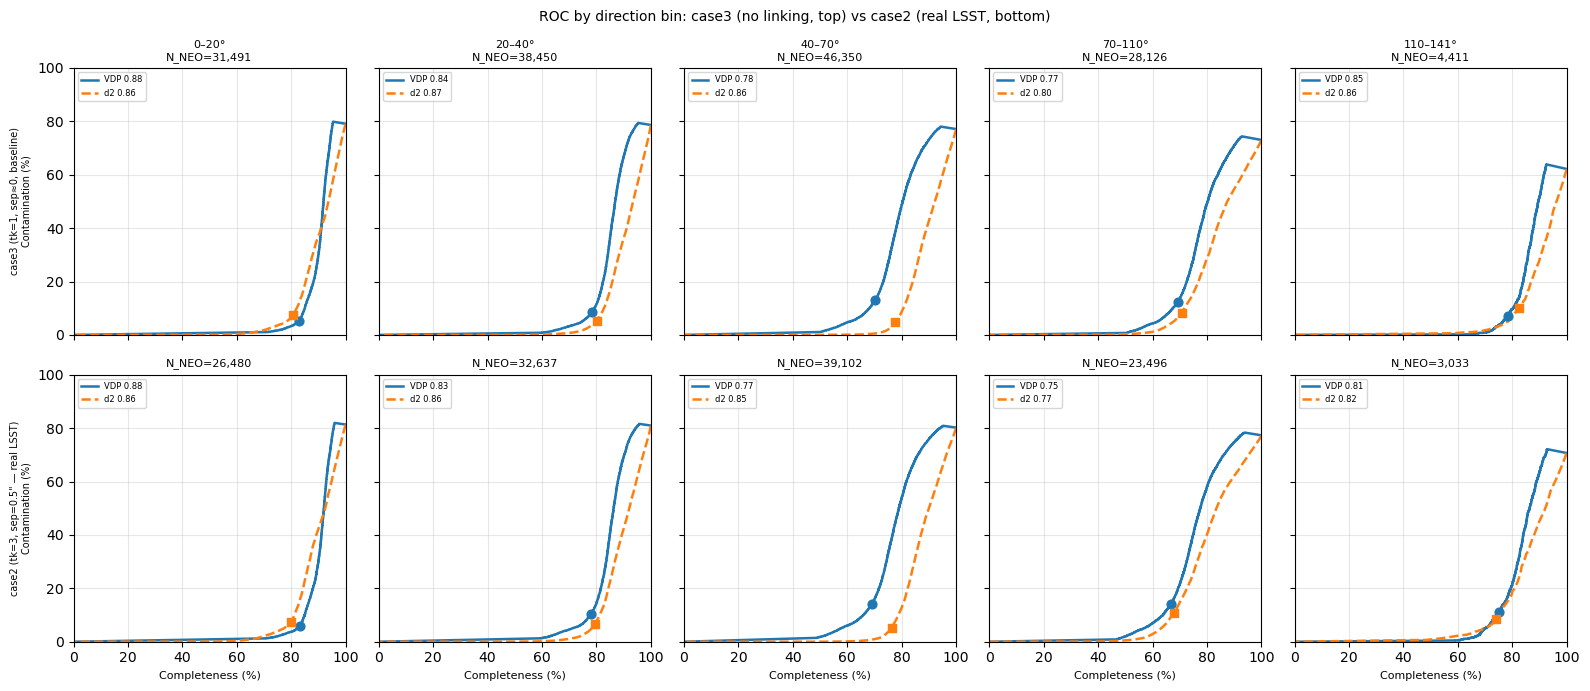

In [10]:
# ── 2×5 ROC grid: case3 (top) vs case2 (bottom), one column per direction bin ─
compare_cases = ['case3', 'case2']
fig, axes = plt.subplots(2, 5, figsize=(16, 7), sharex=True, sharey=True)

for row_i, c in enumerate(compare_cases):
    df = cases[c]
    yy_all = df['is_neo'].values
    for col_i, ((lo, hi), blab) in enumerate(zip(BINS, BIN_LABS)):
        ax = axes[row_i, col_i]
        m = ((df.absdlon >= lo) & (df.absdlon < hi)).values
        yy = yy_all[m]
        if yy.sum() < 10:
            ax.text(0.5, 0.5, 'too few NEOs', ha='center', va='center', transform=ax.transAxes, fontsize=8)
            continue
        cv, kv, fv, mcv, mkv = roc_xy(yy, df['P_NEO_vdp'].values[m])
        cd, kd, fd, mcd, mkd = roc_xy(yy, df['P_NEO_d2'].values[m])
        ax.plot(cv, kv, lw=1.8, color=COLORS['VDP'],    label=f'VDP {fv:.2f}')
        ax.plot(cd, kd, lw=1.8, color=COLORS['digest2'], ls='--', label=f'd2 {fd:.2f}')
        ax.scatter([mcv],[mkv], color=COLORS['VDP'],    s=40, zorder=5)
        ax.scatter([mcd],[mkd], color=COLORS['digest2'], s=40, marker='s', zorder=5)
        ax.set_xlim(0,100); ax.set_ylim(0,100)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=6, loc='upper left')
        n_neo = int(yy.sum())
        if row_i == 0:
            ax.set_title(f'{blab}\nN_NEO={n_neo:,}', fontsize=8)
        else:
            ax.set_title(f'N_NEO={n_neo:,}', fontsize=8)
    axes[row_i, 0].set_ylabel(f'{LABELS[c]}\nContamination (%)', fontsize=7)

for ax in axes[1, :]:
    ax.set_xlabel('Completeness (%)', fontsize=8)

fig.suptitle('ROC by direction bin: case3 (no linking, top) vs case2 (real LSST, bottom)', fontsize=10)
plt.tight_layout()
plt.savefig('Figures/case_roc_by_bin.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — Where Does the 16% NEO Loss Go?

Case2's real LSST linking (3 tracklets in 15 days) drops ~16% of NEOs relative to case3.
Here we check whether that loss concentrates in a particular magnitude or direction bin,
which would tell us *which* NEOs the 3-night requirement filters out.

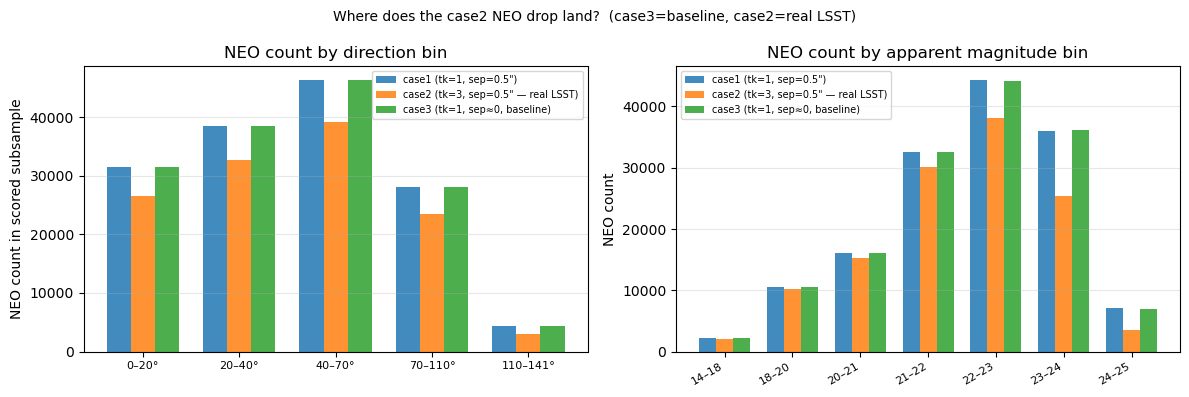

In [11]:
# ── NEO loss by magnitude bin (case3 vs case2) ────────────────────────────────
MAG_EDGES = [14, 18, 20, 21, 22, 23, 24, 25]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: direction-bin bar chart
ax = axes[0]
neo_by_bin = {c: [] for c in cases}
for lo, hi in BINS:
    for c, df in cases.items():
        m = (df.absdlon >= lo) & (df.absdlon < hi) & (df.population == 'NEO')
        neo_by_bin[c].append(int(m.sum()))

xb = np.arange(len(BINS))
w = 0.25
for i, (c, vals) in enumerate(neo_by_bin.items()):
    ax.bar(xb + i*w, vals, width=w, label=LABELS[c], alpha=0.85)
ax.set_xticks(xb + w)
ax.set_xticklabels(BIN_LABS, fontsize=8)
ax.set_ylabel('NEO count in scored subsample')
ax.set_title('NEO count by direction bin')
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.3)

# right: magnitude bin bar chart
ax = axes[1]
neo_by_mag = {c: [] for c in cases}
mag_labs = []
for lo, hi in zip(MAG_EDGES[:-1], MAG_EDGES[1:]):
    mag_labs.append(f'{lo}–{hi}')
    for c, df in cases.items():
        m = (df.mean_mag >= lo) & (df.mean_mag < hi) & (df.population == 'NEO')
        neo_by_mag[c].append(int(m.sum()))

xm = np.arange(len(mag_labs))
for i, (c, vals) in enumerate(neo_by_mag.items()):
    ax.bar(xm + i*w, vals, width=w, label=LABELS[c], alpha=0.85)
ax.set_xticks(xm + w)
ax.set_xticklabels(mag_labs, fontsize=8, rotation=30, ha='right')
ax.set_ylabel('NEO count')
ax.set_title('NEO count by apparent magnitude bin')
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Where does the case2 NEO drop land?  (case3=baseline, case2=real LSST)', fontsize=10)
plt.tight_layout()
plt.savefig('Figures/case_neo_loss_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── fractional NEO loss per bin (case3→case2) ─────────────────────────────────
print('=== Fractional NEO loss: (case2 - case3) / case3  per direction bin ===')
loss_rows = []
for blab, lo_hi in zip(BIN_LABS, BINS):
    lo, hi = lo_hi
    n3 = int(((cases['case3'].absdlon>=lo)&(cases['case3'].absdlon<hi)&(cases['case3'].population=='NEO')).sum())
    n2 = int(((cases['case2'].absdlon>=lo)&(cases['case2'].absdlon<hi)&(cases['case2'].population=='NEO')).sum())
    loss_rows.append({'Bin': blab, 'case3 NEO': n3, 'case2 NEO': n2,
                      'Δ': n2-n3, 'loss %': f'{100*(n2-n3)/n3:.1f}%' if n3 else '—'})
display(pd.DataFrame(loss_rows).set_index('Bin'))

print('\n=== Fractional NEO loss per magnitude bin ===')
loss_mag = []
for mlab, (lo, hi) in zip(mag_labs, zip(MAG_EDGES[:-1], MAG_EDGES[1:])):
    n3 = int(((cases['case3'].mean_mag>=lo)&(cases['case3'].mean_mag<hi)&(cases['case3'].population=='NEO')).sum())
    n2 = int(((cases['case2'].mean_mag>=lo)&(cases['case2'].mean_mag<hi)&(cases['case2'].population=='NEO')).sum())
    loss_mag.append({'Mag': mlab, 'case3 NEO': n3, 'case2 NEO': n2,
                     'Δ': n2-n3, 'loss %': f'{100*(n2-n3)/n3:.1f}%' if n3 else '—'})
display(pd.DataFrame(loss_mag).set_index('Mag'))

=== Fractional NEO loss: (case2 - case3) / case3  per direction bin ===


,case3 NEO,case2 NEO,Δ,loss %
Bin,,,,
0–20°,31491,26480,-5011,-15.9%
20–40°,38450,32637,-5813,-15.1%
40–70°,46350,39102,-7248,-15.6%
70–110°,28126,23496,-4630,-16.5%
110–141°,4411,3033,-1378,-31.2%



=== Fractional NEO loss per magnitude bin ===


,case3 NEO,case2 NEO,Δ,loss %
Mag,,,,
14–18,2153,2063,-90,-4.2%
18–20,10622,10221,-401,-3.8%
20–21,16056,15208,-848,-5.3%
21–22,32631,30095,-2536,-7.8%
22–23,44240,38180,-6060,-13.7%
23–24,36180,25421,-10759,-29.7%
24–25,6931,3551,-3380,-48.8%
